# This is the file for my Artifical intelligence class assignment 2 - "Search!!"

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn as sk
from sklearn.metrics import r2_score, mean_squared_error
import optuna
import plotly.io as pio
pio.renderers.default = 'notebook'
from sklearn.model_selection import cross_val_score
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate
)
optuna.logging.set_verbosity(optuna.logging.WARNING)  # cleaner output
pio.renderers.default = 'notebook'                    # inline plotly charts
from sklearn.ensemble import RandomForestRegressor

Should be making a random forest regressor method

In [55]:
dataset = pd.read_csv('student.csv')
#x = dataset.iloc[:, 3:-2].values # removes first 3 and last 2 columns
x = dataset.iloc[:, [3, 4, 5,13]].values
y = dataset.iloc[:, -2] # removes second last column
#print(y)
#x

### Splitting the dataset into training set and test set

In [56]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)

### Feature Scaling (so magnitude of variables doesn't cause improper impact)

In [57]:
#from sklearn.preprocessing import StandardScaler
#sc = StandardScaler()
#x_train = sc.fit_transform(x_train)
#x_test = sc.transform(x_test)

### Training the Random Forest Regressor model on the Training set, and tuning the hyperparameters using optuna

In [58]:
def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 50, 500),
        'max_depth'        : trial.suggest_int('max_depth', 2, 30),
        'max_features'     : trial.suggest_categorical('max_features', ['sqrt', 'log2', None])  # features per split

    }
    model = RandomForestRegressor(**params, random_state=0)
    score = cross_val_score(model, x_train, y_train, cv=5, scoring='r2', n_jobs=-1)

    return score.mean()


### Optuna Study

In [59]:
study = optuna.create_study(direction='maximize')        # we want to maximise R²
study.optimize(objective, n_trials=100, show_progress_bar=True)
# calls objective() 100 times, each time trying smarter hyperparameter combinations

Best trial: 81. Best value: -0.000229107: 100%|██████████| 100/100 [06:15<00:00,  3.76s/it]


In [60]:
# ── Print Best Results ────────────────────────────────────────────────────────
print("Best Parameters:", study.best_params)   # the winning hyperparameter combination
print("Best R² Score:  ", study.best_value)    # the R² score those params achieved

Best Parameters: {'n_estimators': 175, 'max_depth': 2, 'max_features': None}
Best R² Score:   -0.0002291073826627743


Test R²: -0.002
Test RMSE: 17.245


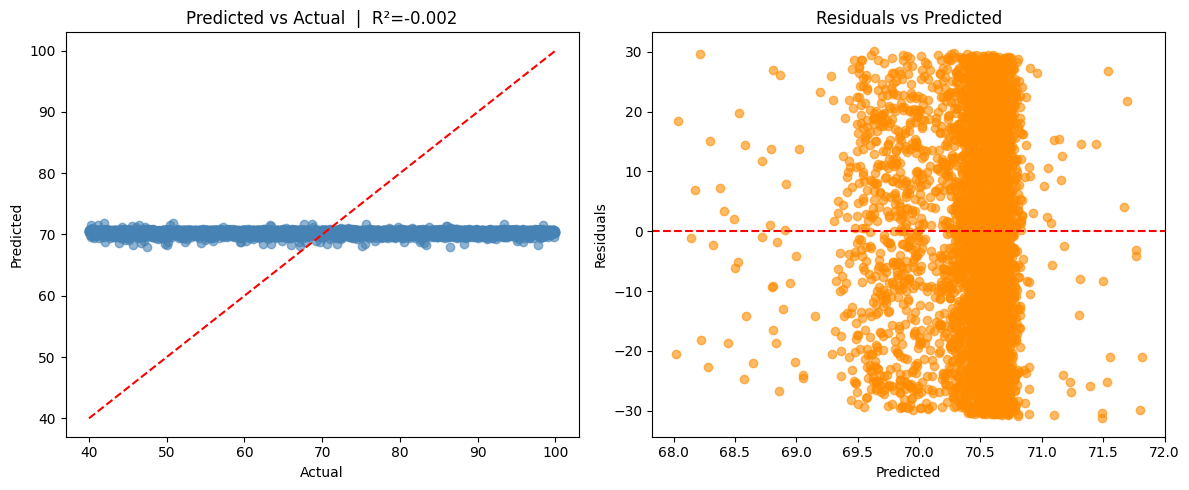

In [61]:
best_regressor = RandomForestRegressor(**study.best_params, random_state=0)
best_regressor.fit(x_train, y_train)
y_pred = best_regressor.predict(x_test)
# ── Evaluate ──────────────────────────────────────────────────────────────────
r2   = r2_score(y_test, y_pred)                          # how well predictions match actuals (1.0 is perfect)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))       # average prediction error in original units
print(f"Test R²: {r2:.3f}")
print(f"Test RMSE: {rmse:.3f}")

# ── Plot Results ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))          # create 2 side by side plots

# Plot 1 — Predicted vs Actual
ax = axes[0]
ax.scatter(y_test, y_pred, color='steelblue', alpha=0.6) # each dot is one prediction
min_val, max_val = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--')   # perfect prediction line
ax.set_xlabel('Actual')
ax.set_ylabel('Predicted')
ax.set_title(f'Predicted vs Actual  |  R²={r2:.3f}')

# Plot 2 — Residuals (prediction errors)
ax = axes[1]
residuals = y_test.values - y_pred                       # difference between actual and predicted
ax.scatter(y_pred, residuals, color='darkorange', alpha=0.6)
ax.axhline(0, color='red', linestyle='--')               # zero error line — dots should scatter around this
ax.set_xlabel('Predicted')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Predicted')

plt.tight_layout()                                       # prevents plots overlapping
plt.show()    

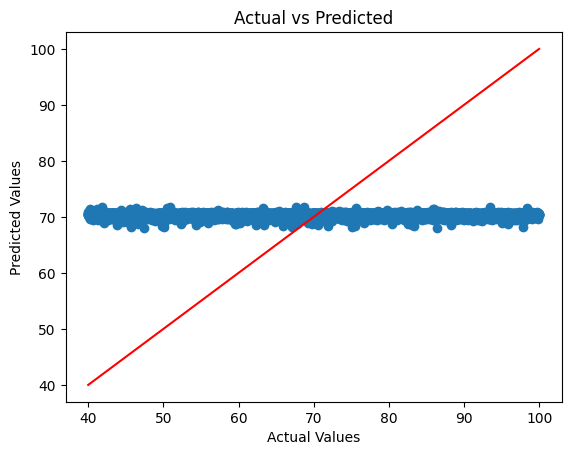

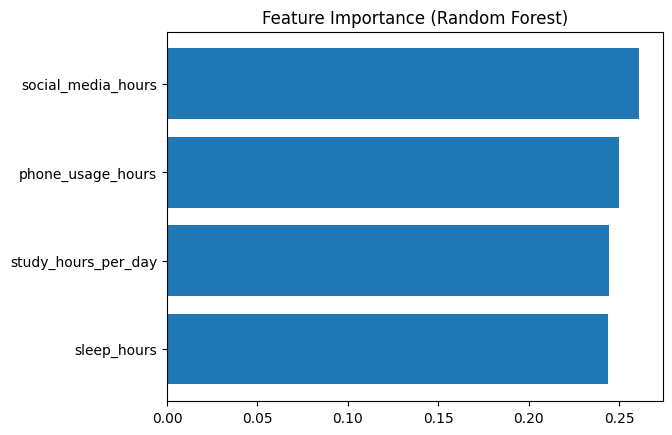

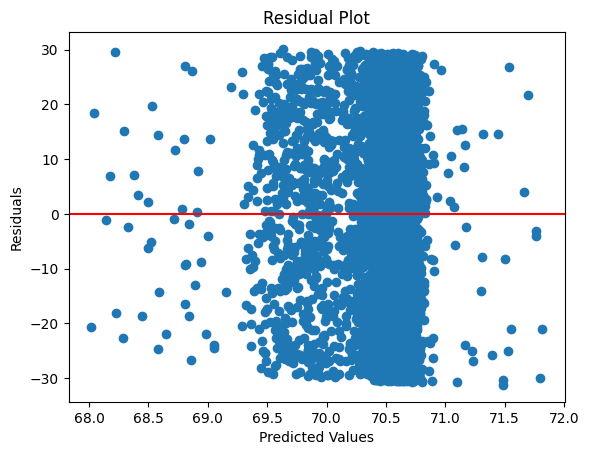

In [62]:
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)],
         [min(y_test), max(y_test)],
         color='red')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.show()

import pandas as pd
import matplotlib.pyplot as plt

importances = regressor.feature_importances_
feature_names = dataset.columns[3:-2]  # adjust if necessary

# Sort by importance
indices = importances.argsort()

plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.title("Feature Importance (Random Forest)")
plt.show()

residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()